In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

: 

In [44]:
# upload the dataset
df = pd.read_csv('./logisticRegression/data.csv')

print(df.head())



   age  salary  purchased
0   58   62107          1
1   48  106202          1
2   34   71663          1
3   27   35708          0
4   40  111906          1


In [45]:
# create the X and y variables
x = df[["age","salary"]]
y = df[['purchased']]

In [46]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# create the model
model = LogisticRegression()
model.fit(x_train, y_train)  

/Users/ankit/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [47]:
# predict
y_pred = model.predict(x_test)
pred_prob = model.predict_proba(x_test)
print(y_pred[:10])
print(pred_prob[:5])

[1 1 0 1 1 1 1 1 0 1]
[[1.42403313e-02 9.85759669e-01]
 [2.41110242e-04 9.99758890e-01]
 [8.63437861e-01 1.36562139e-01]
 [1.21763173e-06 9.99998782e-01]
 [1.70010343e-07 9.99999830e-01]]


In [48]:
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [49]:
# Check how many unique values species have
df["species"].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [50]:
# Check any value is null or not
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [51]:
# Remove setosa for data because we are using logistic regression it perform better with binary classification not multi classification
df=df[df["species"]!="setosa"]

In [52]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor


In [53]:
# Now have to perform map in foam of 0 and 1.
df["species"]=df["species"].map({"versicolor":0,"virginica":1})


In [54]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,0
51,6.4,3.2,4.5,1.5,0
52,6.9,3.1,4.9,1.5,0
53,5.5,2.3,4.0,1.3,0
54,6.5,2.8,4.6,1.5,0


In [55]:
# Split dataset into dependent and independent features
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [56]:
X

,sepal_length,sepal_width,petal_length,petal_width
50,7.0,3.2,4.7,1.4
51,6.4,3.2,4.5,1.5
52,6.9,3.1,4.9,1.5
53,5.5,2.3,4.0,1.3
54,6.5,2.8,4.6,1.5
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [57]:
y

50     0
51     0
52     0
53     0
54     0
      ..
145    1
146    1
147    1
148    1
149    1
Name: species, Length: 100, dtype: int64

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [59]:
from sklearn.linear_model import LogisticRegression

classifier =LogisticRegression()

In [60]:
from sklearn.model_selection import GridSearchCV

parameter={"penalty":["l1","l2","elasticnet"],"C":[1,2,3,4,5,6,10,20,30,40,50],"max_iter":[100,200,300]}

In [61]:
classifier_regressor = GridSearchCV(classifier,param_grid=parameter,scoring="accuracy",cv=5)

In [62]:
classifier_regressor.fit(X_train,y_train)

/Users/ankit/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
330 fits failed out of a total of 495.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
165 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/ankit/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/ankit/Library/Python/3.9/lib/python/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/ankit/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    s

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [1, 2, 3, 4, 5, 6, 10, 20, 30, 40, 50],
                         'max_iter': [100, 200, 300],
                         'penalty': ['l1', 'l2', 'elasticnet']},
             scoring='accuracy')

In [63]:
print(classifier_regressor.best_params_)

{'C': 1, 'max_iter': 100, 'penalty': 'l2'}


In [64]:
print(classifier_regressor.best_score_)

0.9733333333333334


In [65]:
# Prediction
y_predi=classifier_regressor.predict(X_test)

In [66]:
# Accuracy score
from sklearn.metrics import accuracy_score,classification_report


In [67]:
scores = accuracy_score(y_predi,y_test)
print(scores)

0.92


In [68]:
print(classification_report(y_predi,y_test))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.91      0.91      0.91        11

    accuracy                           0.92        25
   macro avg       0.92      0.92      0.92        25
weighted avg       0.92      0.92      0.92        25



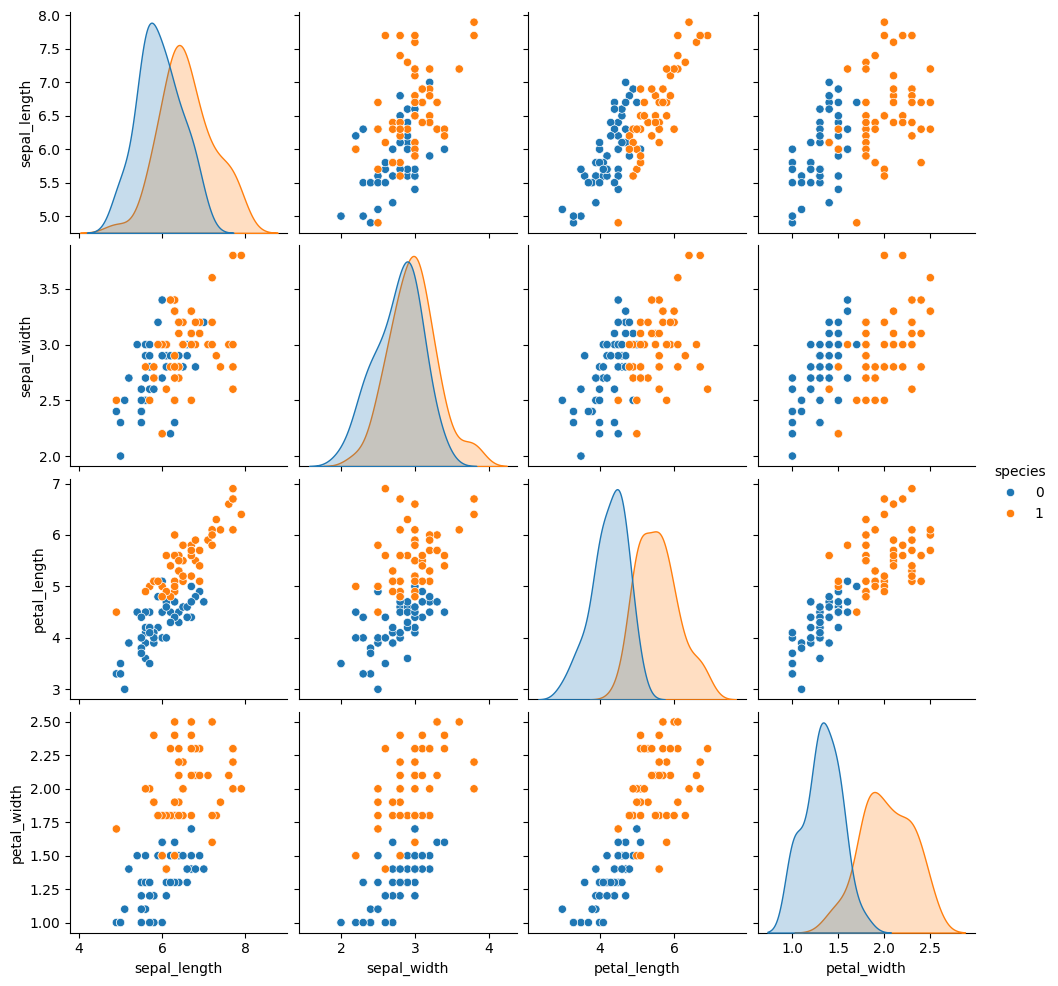

In [70]:
# EDA
sns.pairplot(df,hue="species")

In [72]:
# If you want to see corelation between them
df.corr()

,sepal_length,sepal_width,petal_length,petal_width,species
sepal_length,1.000000,0.553855,0.828479,0.593709,0.494305
sepal_width,0.553855,1.000000,0.519802,0.566203,0.308080
petal_length,0.828479,0.519802,1.000000,0.823348,0.786424
petal_width,0.593709,0.566203,0.823348,1.000000,0.828129
species,0.494305,0.308080,0.786424,0.828129,1.000000
